In [210]:
import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, auc, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorboard.backend.event_processing import event_accumulator
from torch.amp import GradScaler
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoConfig, AutoFeatureExtractor, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split

import warnings
warnings.simplefilter("ignore", UserWarning)

def filter_participants(df, participant_col, file_col, min_files=5, max_files=15, seed=42):
    """
    Normalize participant-level sample counts.
    - Remove participants with < min_files
    - Randomly downsample participants with > max_files
    - Keep only participants within the [min_files, max_files] band
    """
    # Compute counts
    counts = df.groupby(participant_col)[file_col].count()

    # Identify cohorts
    drop_ids = counts[counts < min_files].index
    downsample_ids = counts[counts > max_files].index

    # Filter low-volume participants
    df_filtered = df[~df[participant_col].isin(drop_ids)]

    # Downsample oversized participants
    output_frames = []
    for pid, group in df_filtered.groupby(participant_col):
        if pid in downsample_ids:
            group = group.sample(n=max_files, random_state=seed)
        output_frames.append(group)

    return pd.concat(output_frames, ignore_index=True)


def balance_participants(
    df,
    participant_col="participant",
    label_col="disease_status",
    ratio=1.0,
    seed=42,
    minority_label=None,
):
    """
    Balances the dataset by sampling participants, not individual rows.

    minority_label:
        None → auto-detect minority class based on participant counts
        0 or 1 → force a specific class to be treated as minority
    """

    # Participant → label mapping
    p_map = df.groupby(participant_col)[label_col].first()

    # Participant counts per class
    counts = p_map.value_counts()

    # Determine minority size
    if minority_label is None:
        minority_size = counts.min()
    else:
        # Forced minority: its size = actual participant count of that label
        minority_size = counts[minority_label]

    # Cap for majority classes
    majority_cap = int(minority_size * ratio)

    keep_pids = []

    for label in counts.index:
        pids = p_map[p_map == label]

        if label == minority_label:
            # Keep minority participants fully
            keep_pids.extend(pids.index)
        else:
            # Apply capping to majority groups
            if len(pids) > majority_cap:
                pids = pids.sample(majority_cap, random_state=seed)
            keep_pids.extend(pids.index)

    return df[df[participant_col].isin(keep_pids)].reset_index(drop=True)

def sample_rows_by_participant(df, target_rows=3042, participant_col="participant", label_col="disease_status", random_state=42):
    """
    Sample rows from a dataframe per participant while roughly balancing classes.

    Args:
        df (pd.DataFrame): DataFrame containing participants and labels.
        target_rows (int): Approximate total number of rows to sample.
        participant_col (str): Column name for participant IDs.
        label_col (str): Column name for labels.
        random_state (int): Seed for reproducibility.

    Returns:
        pd.DataFrame: Sampled dataframe.
    """
    # Group participants by their label
    participants = df.groupby(participant_col)[label_col].first().reset_index()

    # Shuffle participants per class
    classes = participants[label_col].unique()
    class_participants = {}
    for c in classes:
        class_participants[c] = participants[participants[label_col] == c].sample(frac=1, random_state=random_state)

    # Helper to select participants until target rows reached
    def select_participants(part_df, target_rows):
        selected = []
        total_rows = 0
        for p in part_df[participant_col]:
            part_rows = len(df[df[participant_col] == p])
            if total_rows + part_rows > target_rows:
                break
            selected.append(p)
            total_rows += part_rows
        return selected

    # Roughly split target rows evenly across classes
    rows_per_class = target_rows // len(classes)
    selected_participants = []
    for c in classes:
        selected_participants += select_participants(class_participants[c], rows_per_class)

    # Filter original dataframe
    df_sampled = df[df[participant_col].isin(selected_participants)]

    return df_sampled


def assign_split_column(
    df,
    participant_col="participant",
    label_col="disease_status",
    train_ratio=0.7,  # adjusted to leave space for val
    val_ratio=0.1,    # fraction of participants for validation
    seed=42
):
    """
    Stratified participant split into train/val/test.
    Guarantees:
        • No participant overlap
        • Class-wise train/val/test ratio per participant
        • Approximate row-level ratios
    """
    # Participant → label
    p_map = df.groupby(participant_col)[label_col].first()

    train_pids = []
    val_pids = []
    test_pids = []

    rng = np.random.default_rng(seed)

    for label in p_map.unique():
        pids = p_map[p_map == label].index
        n_total = len(pids)
        
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)
        
        # shuffle participants
        shuffled = rng.permutation(pids)
        train_sel = shuffled[:n_train]
        val_sel = shuffled[n_train:n_train+n_val]
        test_sel = shuffled[n_train+n_val:]

        train_pids.extend(train_sel)
        val_pids.extend(val_sel)
        test_pids.extend(test_sel)

    # assign split
    df = df.copy()
    df["split"] = "train"
    df.loc[df[participant_col].isin(val_pids), "split"] = "val"
    df.loc[df[participant_col].isin(test_pids), "split"] = "test"

    return df


def encode_participants(df, participant_col="participant"):
    """
    Encode participants as numeric speaker IDs.

    Args:
        df (pd.DataFrame): DataFrame containing a participant column.
        participant_col (str): Column name for participant IDs.
        new_col (str): Name of the new numeric column.

    Returns:
        pd.DataFrame: DataFrame with an additional numeric speaker_id column.
    """
    df = df.copy()
    participant_mapping = {p: i for i, p in enumerate(df[participant_col].unique())}
    df[participant_col] = df[participant_col].map(participant_mapping)
    return df

In [215]:
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')
df_longi = df_longi.rename(columns={"tb_status": "disease_status"})
df_longi = filter_participants(df_longi, "participant", "path_file", min_files=10, max_files=15, seed=42)
df_longi = balance_participants(df_longi, participant_col="participant", label_col="disease_status", ratio=0.5, minority_label=1, seed=42)
df_longi = assign_split_column(df_longi)
df_longi["db"] = 0
df_longi = df_longi[['path_file', 'participant', 'sex', 'disease_status', 'split', 'db']]
#print(df_longi['disease_status'].value_counts())

df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')
df_solic = df_solic.rename(columns={"tb_status": "disease_status"})
df_solic = filter_participants(df_solic, "participant", "path_file", min_files=10, max_files=15, seed=42)
df_solic = balance_participants(df_solic, participant_col="participant", label_col="disease_status", ratio=0.5, minority_label=1, seed=42)
df_solic = assign_split_column(df_solic)
df_solic["db"] = 1
df_solic = df_solic[['path_file', 'participant', 'sex', 'disease_status', 'split', 'db']]
#print(df_solic['disease_status'].value_counts())

df_tbscreen_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_longitudinal.csv')
df_tbscreen_longi = filter_participants(df_tbscreen_longi, "participant", "path_file", min_files=10, max_files=15, seed=42)
df_tbscreen_longi = balance_participants(df_tbscreen_longi, participant_col="participant", label_col="disease_status", ratio=0.5, minority_label=1, seed=42)
df_tbscreen_longi = assign_split_column(df_tbscreen_longi)
df_tbscreen_longi["db"] = 2
df_tbscreen_longi = df_tbscreen_longi[['path_file', 'participant', 'sex', 'disease_status', 'split', 'db']]
#print(df_tbscreen_longi['disease_status'].value_counts())

df_tbscreen_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_longitudinal.csv')
df_tbscreen_solic = filter_participants(df_tbscreen_solic, "participant", "path_file", min_files=10, max_files=15, seed=42)
df_tbscreen_solic = balance_participants(df_tbscreen_solic, participant_col="participant", label_col="disease_status", ratio=0.5, minority_label=1, seed=42)
df_tbscreen_solic = assign_split_column(df_tbscreen_solic)
df_tbscreen_solic["db"] = 3
df_tbscreen_solic = df_tbscreen_solic[['path_file', 'participant', 'sex', 'disease_status', 'split', 'db']]
#print(df_tbscreen_solic['disease_status'].value_counts())

df_concat = pd.concat([df_longi, df_solic, df_tbscreen_longi, df_tbscreen_solic], axis=0, ignore_index=True)
df_concat['disease_status'].value_counts()
print(df_concat[df_concat['split'] == 'train']['disease_status'].value_counts())
print(df_concat[df_concat['split'] == 'val']['disease_status'].value_counts())
print(df_concat[df_concat['split'] == 'test']['disease_status'].value_counts())

disease_status
1    4037
0    1796
Name: count, dtype: int64
disease_status
1    579
0    241
Name: count, dtype: int64
disease_status
1    1173
0     580
Name: count, dtype: int64


In [ ]:
df_train_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.train')
df_val_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.val')
df_test_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.test')

df_train_ukcovid = df_train_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})
df_val_ukcovid = df_val_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})
df_test_ukcovid = df_test_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})

df_train_ukcovid = filter_participants(df_train_ukcovid, "participant", "path_file", min_files=10, max_files=15, seed=42)
df_val_ukcovid = filter_participants(df_val_ukcovid, "participant", "path_file", min_files=10, max_files=15, seed=42)
df_test_ukcovid = filter_participants(df_test_ukcovid, "participant", "path_file", min_files=10, max_files=15, seed=42)

df_train_ukcovid = sample_rows_by_participant(df_train_ukcovid, target_rows=2241, participant_col="participant", label_col="disease_status")
df_val_ukcovid = sample_rows_by_participant(df_val_ukcovid, target_rows=338, participant_col="participant", label_col="disease_status")
df_test_ukcovid = sample_rows_by_participant(df_test_ukcovid, target_rows=593, participant_col="participant", label_col="disease_status")

df_train_ukcovid['split'] = "train"
df_val_ukcovid['split'] = "val"
df_test_ukcovid['split'] = "test"

df_ukcovid = pd.concat([df_train_ukcovid, df_val_ukcovid, df_test_ukcovid], axis=0, ignore_index=True)
df_ukcovid["db"] = 4
df_ukcovid['disease_status'] = 0

df_concat = pd.concat([df_concat, df_ukcovid], axis=0, ignore_index=True)
df_concat = encode_participants(df_concat)
df_concat['sex']  = df_concat['sex'].replace({'Male': 0, 'Female': 1})

print(df_concat['disease_status'].value_counts())

/tmp/ipykernel_1245036/445389127.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_concat['sex']  = df_concat['sex'].replace({'Male': 0, 'Female': 1})


In [220]:
for split_name in df_concat['split'].unique():
    split_df = df_concat[df_concat['split'] == split_name].copy()
    filename = f"/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.{split_name}"
    split_df.to_csv(filename, index=False)
    print(f"Saved {split_name} split: {len(split_df)} rows → {filename}")

Saved train split: 8058 rows → /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.train
Saved test split: 2334 rows → /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.test
Saved val split: 1146 rows → /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/metadata.csv.val


In [ ]:
df_tbscreen = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_solicited.csv')

df_train_tbscreen = filter_participants(df_train_tbscreen, "participant", "path_file", min_files=5, max_files=15, seed=42)
df_train_tbscreen = balance_participants(df_train_tbscreen, participant_col="participant", label_col="disease_status", ratio=0.5, minority_label=1, seed=42)
print(df_train_tbscreen['disease_status'].value_counts())

In [ ]:



df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')
df_solic = df_solic.rename(columns={"tb_status": "disease_status"})
df_solic = filter_participants(df_solic, "participant", "path_file", min_files=5, max_files=15, seed=42)


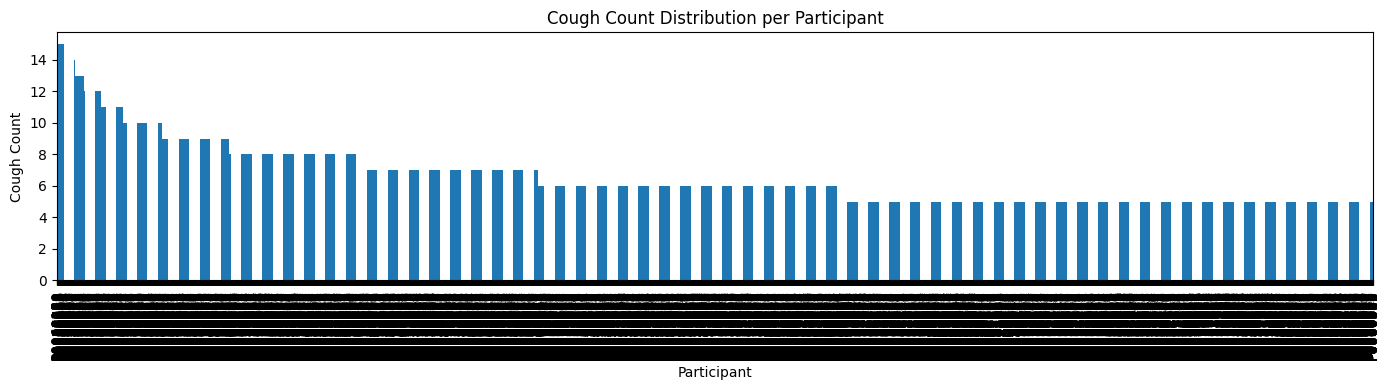

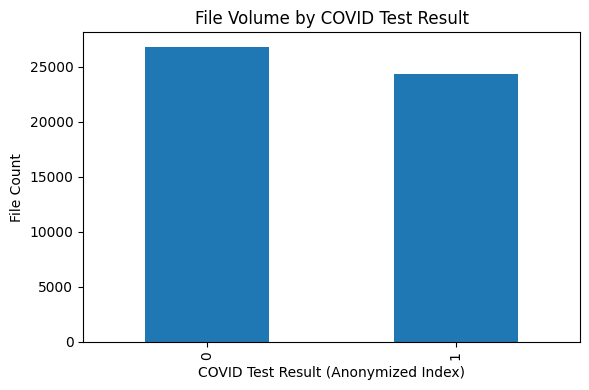

In [40]:
# ------------------------------------------------------------
# 1. Participant vs File Count (Anonymized IDs)
# ------------------------------------------------------------
cough_volume = (
    df_train_ukcovid
      .groupby("participant")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,4))
cough_volume.plot(kind="bar")
plt.title("Cough Count Distribution per Participant")
plt.xlabel("Participant")
plt.ylabel("Cough Count")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. COVID Test Result vs File Count (Also anonymized)
# ------------------------------------------------------------
covid_counts = (
    df_train_ukcovid.groupby("disease_status")["path_file"]
      .count()
      .sort_values(ascending=False)
      .reset_index(drop=True)     # anonymize: 0,1,2,...
)

plt.figure(figsize=(6,4))
covid_counts.plot(kind="bar")
plt.title("File Volume by COVID Test Result")
plt.xlabel("COVID Test Result (Anonymized Index)")
plt.ylabel("File Count")
plt.tight_layout()
plt.show()

disease_status
1    2003
0     982
Name: count, dtype: int64


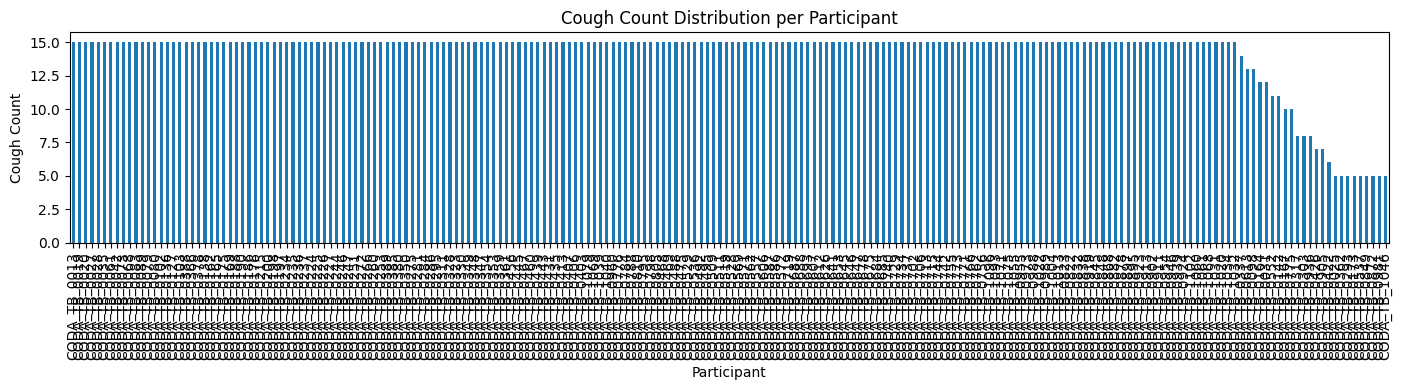

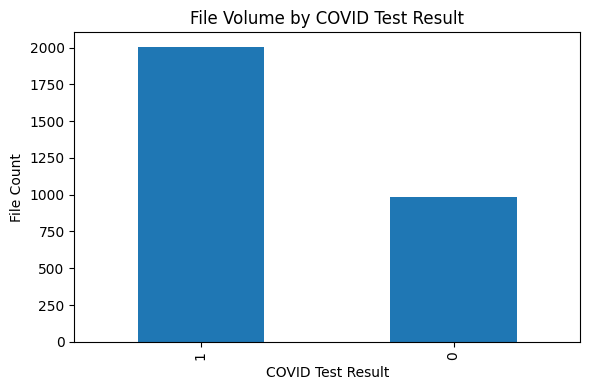

In [ ]:


cough_volume = (
    df_longi
      .groupby("participant")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,4))
cough_volume.plot(kind="bar")
plt.title("Cough Count Distribution per Participant")
plt.xlabel("Participant")
plt.ylabel("Cough Count")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. COVID Test Result vs File Count
# ------------------------------------------------------------
covid_counts = (
    df_longi.groupby("disease_status")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
covid_counts.plot(kind="bar")
plt.title("File Volume by COVID Test Result")
plt.xlabel("COVID Test Result")
plt.ylabel("File Count")
plt.tight_layout()
plt.show()

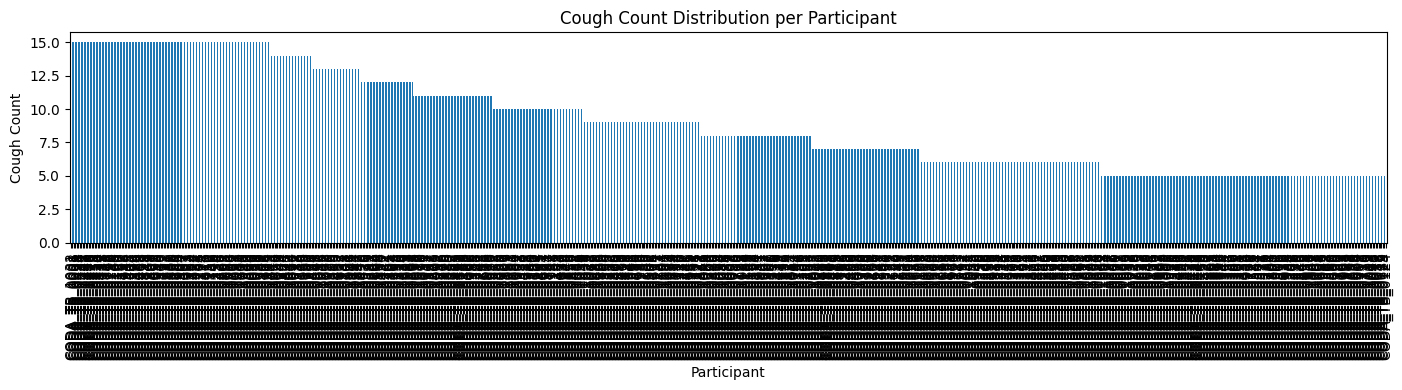

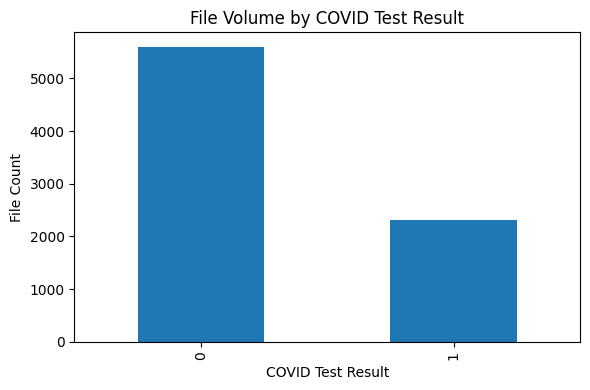

In [ ]:


cough_volume = (
    df_solic
      .groupby("participant")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(14,4))
cough_volume.plot(kind="bar")
plt.title("Cough Count Distribution per Participant")
plt.xlabel("Participant")
plt.ylabel("Cough Count")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. COVID Test Result vs File Count
# ------------------------------------------------------------
covid_counts = (
    df_solic.groupby("disease_status")["path_file"]
      .count()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
covid_counts.plot(kind="bar")
plt.title("File Volume by COVID Test Result")
plt.xlabel("COVID Test Result")
plt.ylabel("File Count")
plt.tight_layout()
plt.show()
